TAREA 1: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

In [56]:
import cv2
import matplotlib.pyplot as plt


In [57]:
# Lee imagen de archivo
img = cv2.imread("mandril.jpg")

# Si hay lectura correcta
if img is not None:
    # Muestra dimensiones
    print(img.shape)

    # Recordar que OpenCV lee las imágenes almacenando en formato BGR, por lo que convertimos para visualizr de forma correcta a RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
else:
    print("Imagen no encontrada")

(512, 512, 3)


In [58]:
# Conversión de la imagen a niveles de grises de la imagen original en BGR
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
print(gris.shape)


(512, 512)


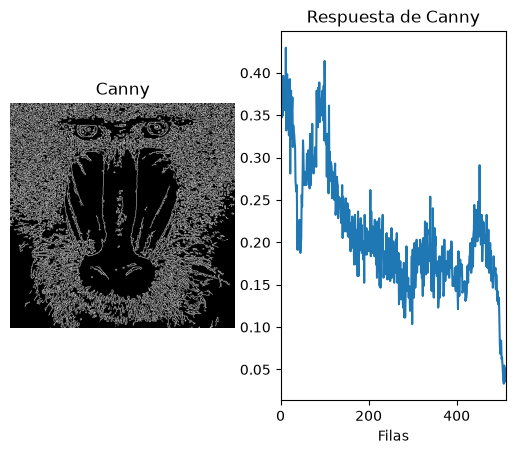

In [59]:
# Obtiene contornos con el operador de Canny
# Parámetros: imagen de entrada, umbral inferior, umbral superior
canny = cv2.Canny(gris, 100, 200)  # prueba a jugar con umbrales (entre 0 y 255)

# Cuenta el número de píxeles blancos (255) por fila
white_pixels_per_row = cv2.reduce(canny, 255, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

# Porcentaje por fila
percentage_per_row = white_pixels_per_row / (255 * canny.shape[1])

# Muestra dicha cuenta gráficamente
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("Filas")
plt.ylabel("% píxeles")
plt.plot(percentage_per_row)
# Rango en x definido por filas
plt.xlim([0, canny.shape[0]])

plt.show()

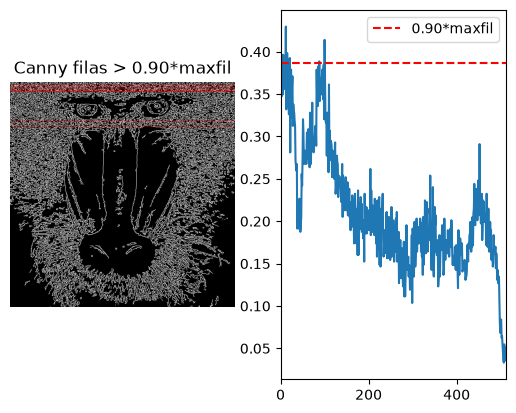

In [ ]:
maxfil = np.max(white_pixels_per_row)
umbral = 0.90 * maxfil
filas_sel = np.where(white_pixels_per_row.flatten() > umbral)[0]

# Imagen de Canny en color (BGR) para poder dibujar en rojo
canny_color = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
for f in filas_sel:
    cv2.line(canny_color, (0, int(f)), (canny.shape[1] - 1, int(f)), (0, 0, 255), 1)

# Muestra la imagen resaltada y el plot con el umbral
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny filas > 0.90*maxfil")
plt.imshow(cv2.cvtColor(canny_color, cv2.COLOR_BGR2RGB))

plt.subplot(1, 2, 2)
plt.ylabel("% píxeles")
plt.plot(percentage_per_row)
plt.axhline(umbral / (255 * canny.shape[1]), color="r", linestyle="--", label="0.90*maxfil")
# Rango en x definido por filas
plt.xlim([0, canny.shape[0]])
plt.legend()

plt.show()

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.